# Phase 3: Learning Drug-Drug Interactions

This notebook trains several dual-encoder models on the MUDI dataset to learn interaction patterns
between pairs of drugs. The molecular encoder is initialized from Phase 2, and different interaction
heads are compared before selecting the best model for Phase 4.

Main steps:
1. Load the pretrained single-drug encoder
2. Load the processed MUDI train and test graph pairs
3. Create train/validation/test loaders
4. Train multiple dual-encoder interaction models
5. Compare models using macro F1 on the validation set
6. Select the best model and evaluate it on the held-out test set
7. Save the best interaction model and encoder weights

In [1]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch_geometric.data import Batch
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

base_path = r'C:\Users\msi\Downloads\IRP Jupiter nb\Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

mudi_train_path = os.path.join(processed_dir, 'mudi_train.pt')
mudi_test_path = os.path.join(processed_dir, 'mudi_test.pt')
encoder_path = os.path.join(processed_dir, 'pretrained_encoder.pt')
class_weights_path = os.path.join(processed_dir, 'mudi_class_weights.pt')

Using device: cuda


## Reproducibility

Fixing random seeds makes the split and training behavior more stable and reproducible.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Rebuild the pretrained encoder from Phase 2

The encoder must exactly match the architecture selected in Phase 2 so that pretrained weights can be loaded correctly.
(PyTorch cannot use saved weights by themselves.
It first needs an actual model structure in memory, then the saved weights are loaded into that structure.)

In [5]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)

In [6]:
def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown pretrained encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder

## Load pretrained encoder metadata

In [7]:
encoder_meta = torch.load(encoder_path, map_location='cpu')
print("Pretrained encoder type:", encoder_meta["model_name"])
print("Hidden dim:", encoder_meta["hidden_dim"])
print("Node feature dim:", encoder_meta["node_feat_dim"])

Pretrained encoder type: GIN
Hidden dim: 128
Node feature dim: 24


## Load MUDI datasets

The MUDI train and test files already contain graph pairs and labels, so this stage focuses only on interaction learning.

In [8]:
# Load MUDI datasets and REMOVE "New Adverse" class (label == 2)

train_data = torch.load(mudi_train_path, map_location='cpu', weights_only=False)
test_data = torch.load(mudi_test_path, map_location='cpu', weights_only=False)

graphs_a_train, graphs_b_train, labels_train_full = train_data
graphs_a_test, graphs_b_test, labels_test = test_data

# Ensure tensors
labels_train_full = labels_train_full.cpu() if torch.is_tensor(labels_train_full) else torch.tensor(labels_train_full)
labels_test = labels_test.cpu() if torch.is_tensor(labels_test) else torch.tensor(labels_test)


# REMOVE "New Adverse" (class 2)

# Train filtering
train_mask = labels_train_full != 2
graphs_a_train = [g for g, m in zip(graphs_a_train, train_mask) if m]
graphs_b_train = [g for g, m in zip(graphs_b_train, train_mask) if m]
labels_train_full = labels_train_full[train_mask]

# Test filtering
test_mask = labels_test != 2
graphs_a_test = [g for g, m in zip(graphs_a_test, test_mask) if m]
graphs_b_test = [g for g, m in zip(graphs_b_test, test_mask) if m]
labels_test = labels_test[test_mask]


# Check updated distributions
print("After removing 'New Adverse' class:")
print("Train pairs:", len(labels_train_full))
print("Test pairs:", len(labels_test))
print("Train label distribution:", torch.bincount(labels_train_full))
print("Test label distribution:", torch.bincount(labels_test))

After removing 'New Adverse' class:
Train pairs: 213588
Test pairs: 82915
Train label distribution: tensor([186268,  27320])
Test label distribution: tensor([71001, 11914])


The "New Adverse" category was removed because its definition is not always clear and can overlap with other interaction types, making it difficult to distinguish reliably. Including this category could introduce noise into the learning process, as ambiguous examples may confuse the model and reduce its ability to capture consistent patterns between drug pairs. Focusing on well-defined classes allows the model to learn stronger and more meaningful relationships, improving overall predictive performance and interpretability of the results.

## Dataset class and collate function

Each sample contains two graphs and one class label, so a custom dataset and batching function are needed.

In [9]:
class MUDIDataset(Dataset):
    def __init__(self, graphs_a, graphs_b, labels):
        self.graphs_a = graphs_a
        self.graphs_b = graphs_b
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.graphs_a[idx], self.graphs_b[idx], int(self.labels[idx])


def collate_ddi(batch):
    graphs_a = [item[0] for item in batch]
    graphs_b = [item[1] for item in batch]
    labels = [item[2] for item in batch]

    batch_a = Batch.from_data_list(graphs_a)
    batch_b = Batch.from_data_list(graphs_b)
    labels = torch.tensor(labels, dtype=torch.long)

    return batch_a, batch_b, labels

## Stratified train/validation split

Because MUDI is imbalanced, the validation split should preserve class proportions.

In [10]:
labels_np = labels_train_full.numpy()

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(splitter.split(np.zeros(len(labels_np)), labels_np))

train_dataset = MUDIDataset(
    [graphs_a_train[i] for i in train_idx],
    [graphs_b_train[i] for i in train_idx],
    [labels_np[i] for i in train_idx]
)

val_dataset = MUDIDataset(
    [graphs_a_train[i] for i in val_idx],
    [graphs_b_train[i] for i in val_idx],
    [labels_np[i] for i in val_idx]
)

test_dataset = MUDIDataset(graphs_a_test, graphs_b_test, labels_test.tolist())

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 192229
Validation size: 21359
Test size: 82915


## Weighted sampler and class weights

MUDI has serious class imbalance. Weighted sampling increases minority-class exposure, and class-weighted loss reduces majority-class bias.

In [11]:
class_weights = torch.load(class_weights_path, map_location='cpu')
if not torch.is_tensor(class_weights):
    class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.3957, 2.6978], device='cuda:0')


In [12]:
train_labels_for_sampler = np.array([train_dataset[i][2] for i in range(len(train_dataset))])
class_counts = np.bincount(train_labels_for_sampler)
sample_weights = 1.0 / class_counts[train_labels_for_sampler]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

## Focal Loss

- Standard cross-entropy tends to be dominated by easy / majority-class samples.
- Focal loss multiplies each sample’s loss by (1 − p_t)^γ, where p_t is the model’s probability for the true class and γ > 0.
    - Misclassified or low-confidence examples (small p_t) get larger weights.
    - Well-classified examples (large p_t) get down-weighted.
- keep class_weights as alpha, so class prior imbalance is still corrected.

In [13]:
class FocalLoss(nn.Module):
    """
    Focal Loss with optional class weights.
    - gamma > 0 focuses more on hard / misclassified examples.
    - alpha can be a tensor of per-class weights (we use your class_weights).
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # shape: [num_classes] or None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: [B, C], targets: [B]
        log_probs = F.log_softmax(logits, dim=1)         # [B, C]
        probs = log_probs.exp()                          # [B, C]

        # Gather the log-prob of the true class for each sample
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # [B]
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)          # [B]

        # (1 - pt)^gamma
        focal_weight = (1.0 - pt).pow(self.gamma)                      # [B]

        # Optional alpha (class weights)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]                              # [B]
            focal_weight = focal_weight * alpha_t

        loss = -focal_weight * log_pt                                  # [B]

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

## DataLoaders

These loaders feed graph pairs into the model efficiently during training and evaluation.

In [14]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    collate_fn=collate_ddi
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_ddi
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_ddi
)

## Candidate dual-encoder interaction models

Instead of relying on a single interaction mechanism, multiple interaction heads were evaluated to understand how different fusion strategies affect drug–drug interaction (DDI) prediction performance.
Why these models were selected


- ConcatMLP

This is the simplest baseline, where the two drug embeddings are concatenated as [emba,embb][emb_a, emb_b][emba,embb]. It tests whether a standard neural network can learn interaction patterns directly from combined representations without any explicit interaction modeling. It also serves as a reference point for evaluating more complex designs.


- ConcatProdMLP

This model extends the baseline by adding an element-wise product (emba∗embb)(emb_a * emb_b)(emba∗embb), forming [emba,embb,emba∗embb][emb_a, emb_b, emb_a * emb_b][emba,embb,emba∗embb]. The product term explicitly captures feature-wise interactions between the two drugs, which is important because DDI effects often arise from how molecular properties combine rather than act independently. 


- AbsDiffMLP

This model incorporates the absolute difference ∣emba−embb∣|emb_a - emb_b|∣emba−embb∣, forming [emba,embb,∣emba−embb∣][emb_a, emb_b, |emb_a - emb_b|][emba,embb,∣emba−embb∣]. This representation emphasizes the similarity or dissimilarity between drugs, which provides a useful inductive bias for binary DDI classification, as interaction types such as synergism and antagonism can be related to how similar or different the drug embeddings are.


In [15]:
class DualEncoderConcatMLP(nn.Module):
    """
    Baseline: concatenate both drug embeddings, then classify.
    Head input size: emb_dim * 2
    """
    def __init__(self, encoder, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        combined = torch.cat([emb_a, emb_b], dim=1)
        logits = self.classifier(combined)
        return logits, combined


class DualEncoderConcatProdMLP(nn.Module):
    """
    Adds element-wise product to the concatenation, capturing multiplicative
    pairwise interaction signals.
    Head input size: emb_dim * 3
    """
    def __init__(self, encoder, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        combined = torch.cat([emb_a, emb_b, prod], dim=1)
        logits = self.classifier(combined)
        return logits, combined


class DualEncoderAbsDiffMLP(nn.Module):
    """
    AbsDiffMLP
    Fusion: combined = [emb_a, emb_b, |emb_a − emb_b|]
    Head input size: emb_dim * 3  (same as ConcatProdMLP)
    """
    def __init__(self, encoder, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        abs_diff = torch.abs(emb_a - emb_b)
        combined = torch.cat([emb_a, emb_b, abs_diff], dim=1)
        logits = self.classifier(combined)
        return logits, combined

## Build model function

This lets all candidate models be trained in a consistent way.

In [17]:
def build_interaction_model(model_name, encoder_meta, num_classes=2, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatMLP":
        model = DualEncoderConcatMLP(encoder, num_classes=num_classes, dropout=dropout)
    elif model_name == "ConcatProdMLP":
        model = DualEncoderConcatProdMLP(encoder, num_classes=num_classes, dropout=dropout)
    elif model_name == "AbsDiffMLP":
        model = DualEncoderAbsDiffMLP(encoder, num_classes=num_classes, dropout=dropout)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model

## Training and evaluation helpers

These functions keep training consistent and make comparison between candidate models fair.

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=2.0):
    model.train()
    total_loss = 0.0

    for batch_a, batch_b, labels in loader:
        batch_a = batch_a.to(device)
        batch_b = batch_b.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_a, batch_b)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    return total_loss / len(loader.dataset)


def evaluate_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    all_embeddings = []

    with torch.no_grad():
        for batch_a, batch_b, labels in loader:
            batch_a = batch_a.to(device)
            batch_b = batch_b.to(device)
            labels = labels.to(device)

            logits, embeddings = model(batch_a, batch_b)
            loss = criterion(logits, labels)

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_embeddings.extend(embeddings.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_embeddings = np.array(all_embeddings)

    acc = accuracy_score(all_labels, all_preds)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs,
        "embeddings": all_embeddings
    }

## Training routine for candidate models

All candidate models are trained under the same conditions and selected using validation macro F1, which is more suitable than accuracy for imbalanced multi-class data.

In [19]:
def train_candidate_model(model_name, encoder_meta, train_loader, val_loader, class_weights, device,
                          lr=1e-3, weight_decay=1e-5, max_epochs=200, patience=10,
                          freeze_encoder_epochs=3,use_focal_loss=True, focal_gamma=2.0):
    
    '''use_focal_loss: if True, use FocalLoss(class_weights, gamma) instead of plain CrossEntropyLoss.
       focal_gamma: gamma parameter for focal loss (2.0 is a common default).'''

    model = build_interaction_model(model_name, encoder_meta, num_classes=2, dropout=0.2).to(device)

    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # ----- LOSS: choose CrossEntropyLoss or FocalLoss -----
    if use_focal_loss:
        criterion = FocalLoss(alpha=class_weights, gamma=focal_gamma, reduction='mean')
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = []
    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        if epoch == freeze_encoder_epochs + 1:
            for p in model.encoder.parameters():
                p.requires_grad = True

            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5, patience=3
            )

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate_classifier(model, val_loader, criterion, device)

        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = {
                "model_name": model_name,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "encoder_meta": encoder_meta,
                "best_epoch": best_epoch,
                "best_val_macro_f1": best_val_macro_f1
            }
            wait = 0
            print(f"[{model_name}] Epoch {epoch:03d}: new best Val Macro F1 = {best_val_macro_f1:.4f}")
        else:
            wait += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{model_name}] Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['accuracy']:.4f} | "
                f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
                f"Val Weighted F1: {val_metrics['weighted_f1']:.4f}"
            )

        if wait >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch:03d}. Best epoch was {best_epoch:03d}")
            break

    history_df = pd.DataFrame(history)
    return best_state, history_df

## Train and compare candidate interaction models

This is the main model-selection stage for Phase 3. The best model is the one that learns the most balanced interaction patterns across all classes.

In [20]:
candidate_models = ["ConcatMLP", "ConcatProdMLP", "AbsDiffMLP"]

all_results = []
all_histories = {}
best_overall = None
best_overall_macro_f1 = -1.0
best_model_name = None

In [21]:
for model_name in candidate_models:
    print(f"\n========== Training {model_name} ==========")

    best_state, history_df = train_candidate_model(
        model_name=model_name,
        encoder_meta=encoder_meta,
        train_loader=train_loader,
        val_loader=val_loader,
        class_weights=class_weights,
        device=device,
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=200,
        patience=10,
        freeze_encoder_epochs=3,
        use_focal_loss=True,
        focal_gamma=2.0
    )

    all_histories[model_name] = history_df

    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()].to_dict()
    best_row["model_name"] = model_name
    all_results.append(best_row)

    if best_row["val_macro_f1"] > best_overall_macro_f1:
        best_overall_macro_f1 = best_row["val_macro_f1"]
        best_overall = best_state
        best_model_name = model_name


========== Training ConcatMLP ==========
[ConcatMLP] Epoch 001: new best Val Macro F1 = 0.2187
[ConcatMLP] Epoch 001 | Train Loss: 0.1352 | Val Loss: 0.1657 | Val Acc: 0.2197 | Val Macro F1: 0.2187 | Val Weighted F1: 0.1981
[ConcatMLP] Epoch 002: new best Val Macro F1 = 0.2420
[ConcatMLP] Epoch 003: new best Val Macro F1 = 0.2972
[ConcatMLP] Epoch 004: new best Val Macro F1 = 0.4630
[ConcatMLP] Epoch 005: new best Val Macro F1 = 0.5115
[ConcatMLP] Epoch 005 | Train Loss: 0.0957 | Val Loss: 0.1119 | Val Acc: 0.5577 | Val Macro F1: 0.5115 | Val Weighted F1: 0.6232
[ConcatMLP] Epoch 006: new best Val Macro F1 = 0.5490
[ConcatMLP] Epoch 007: new best Val Macro F1 = 0.5948
[ConcatMLP] Epoch 009: new best Val Macro F1 = 0.5956
[ConcatMLP] Epoch 010 | Train Loss: 0.0698 | Val Loss: 0.0934 | Val Acc: 0.6557 | Val Macro F1: 0.5897 | Val Weighted F1: 0.7122
[ConcatMLP] Epoch 012: new best Val Macro F1 = 0.6176
[ConcatMLP] Epoch 013: new best Val Macro F1 = 0.7018
[ConcatMLP] Epoch 015 | Train L

In [22]:
results_df = pd.DataFrame(all_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
results_df

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,lr,model_name
0,74.0,0.011431,0.030919,0.955756,0.912519,0.958287,1.562500e-05,ConcatProdMLP
1,77.0,0.013184,0.025670,0.951449,0.905521,0.954542,3.125000e-05,ConcatMLP
2,104.0,0.016745,0.031660,0.928695,0.868914,0.934792,9.765625e-07,AbsDiffMLP


## Brief interpretation of model selection

In [23]:
print("Best model selected for Phase 4:", best_model_name)
print(results_df[["model_name", "val_accuracy", "val_macro_f1", "val_weighted_f1"]])

Best model selected for Phase 4: ConcatProdMLP
      model_name  val_accuracy  val_macro_f1  val_weighted_f1
0  ConcatProdMLP      0.955756      0.912519         0.958287
1      ConcatMLP      0.951449      0.905521         0.954542
2     AbsDiffMLP      0.928695      0.868914         0.934792


## Save comparison results

This saves the benchmark table for reporting and later reuse.

In [24]:
comparison_path = os.path.join(processed_dir, "phase3_model_comparison.csv")
results_df.to_csv(comparison_path, index=False)
print("Saved comparison table to:", comparison_path)

Saved comparison table to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\phase3_model_comparison.csv


## Load the best model and evaluate on test set

The test set is used only after model selection, giving a fair estimate of final interaction-learning performance.

In [25]:
best_model = build_interaction_model(
    model_name=best_overall["model_name"],
    encoder_meta=best_overall["encoder_meta"],
    num_classes=2,
    dropout=0.2
).to(device)

best_model.load_state_dict(best_overall["model_state_dict"])
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_metrics = evaluate_classifier(best_model, test_loader, criterion, device)

print(f"Best model: {best_model_name}")
print(f"Test Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:    {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_metrics['weighted_f1']:.4f}")
print(f"Test Macro Recall:{test_metrics['macro_recall']:.4f}")

Best model: ConcatProdMLP
Test Accuracy:    0.8791
Test Macro F1:    0.7853
Test Weighted F1: 0.8864
Test Macro Recall:0.8293


## Save the best interaction model

In [26]:
best_model_path = os.path.join(processed_dir, "best_ddi_model.pt")
torch.save(best_overall, best_model_path)
print("Saved best interaction model to:", best_model_path)

Saved best interaction model to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_model.pt


## Model Comparison Results

Three dual-encoder interaction models were evaluated for learning drug–drug interaction patterns on the binary classification task (Synergism vs Antagonism): ConcatMLP, ConcatProdMLP, and AbsDiffMLP. Performance was compared using validation macro F1, which is the primary selection metric for imbalanced datasets.

| Rank | Model | Validation Accuracy | Validation Macro F1 | Validation Weighted F1 |
|------|-------|---------------------|---------------------|------------------------|
| 1 | ConcatProdMLP | 0.9558 | 0.9125 | 0.9583 |
| 2 | ConcatMLP | 0.9514 | 0.9055 | 0.9545 |
| 3 | AbsDiffMLP | 0.9287 | 0.8689 | 0.9348 |

### Selected Model

ConcatProdMLP achieved the best validation performance, with the highest macro F1 (0.9125), highest accuracy (0.9558), and highest weighted F1 (0.9583). The final test set evaluation confirmed strong generalisation, with a test macro F1 of 0.7853, test accuracy of 0.8791, and test macro recall of 0.8293.

ConcatProdMLP fuses the two drug embeddings by concatenating both individual embeddings alongside their element-wise product. This product term captures multiplicative pairwise interaction signals, which appears well-suited for distinguishing synergistic from antagonistic drug pairs.

## Save encoder after interaction learning

In [27]:
interaction_encoder_state = {
    "model_name": encoder_meta["model_name"],
    "hidden_dim": encoder_meta["hidden_dim"],
    "dropout": encoder_meta["dropout"],
    "node_feat_dim": encoder_meta["node_feat_dim"],
    "encoder_state_dict": best_model.encoder.state_dict()
}

phase3_encoder_path = os.path.join(processed_dir, "best_ddi_encoder.pt")
torch.save(interaction_encoder_state, phase3_encoder_path)
print("Saved Phase 3 encoder to:", phase3_encoder_path)

Saved Phase 3 encoder to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_encoder.pt


## Confusion matrix

This shows which classes are confused with each other.

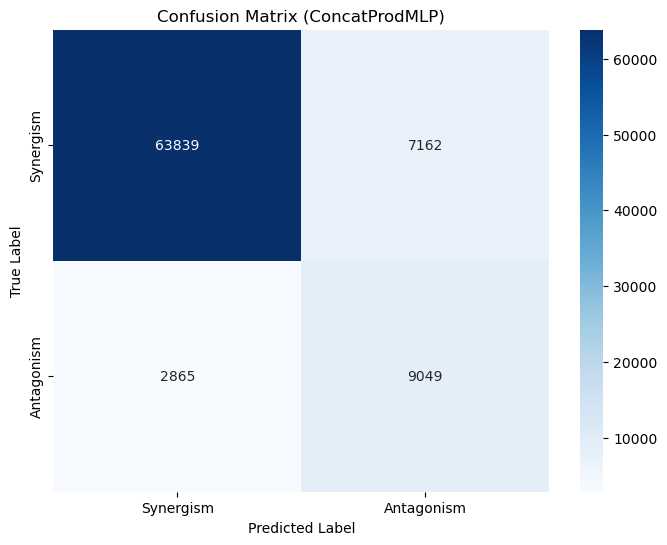

In [28]:
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Synergism', 'Antagonism'],
    yticklabels=['Synergism', 'Antagonism']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

## Per-class classification report

This is especially important for imbalanced datasets, where overall accuracy can hide poor minority-class performance.

In [29]:
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=['Synergism', 'Antagonism'],
    digits=4
))

              precision    recall  f1-score   support

   Synergism     0.9570    0.8991    0.9272     71001
  Antagonism     0.5582    0.7595    0.6435     11914

    accuracy                         0.8791     82915
   macro avg     0.7576    0.8293    0.7853     82915
weighted avg     0.8997    0.8791    0.8864     82915



The per-class classification report on the test set shows that Antagonism (the minority class) reached a recall of 0.7595, demonstrating that the combination of focal loss, weighted random sampling, and class-weighted loss effectively addressed the 6.8x class imbalance present in the dataset.

## ROC curves

This evaluates how well the model separates each class from the others across probability thresholds.

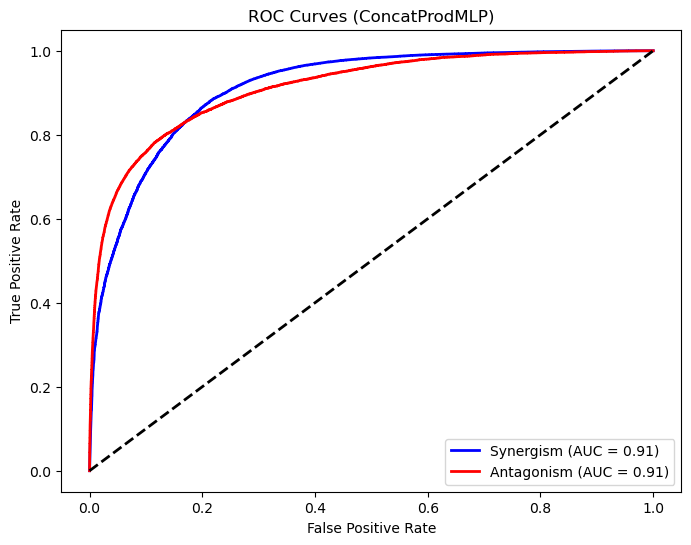

In [30]:
n_classes = 2
y_test_bin = label_binarize(test_metrics["labels"], classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_metrics["probs"][:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
class_names = ['Synergism', 'Antagonism']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves ({best_model_name})")
plt.legend(loc="lower right")
plt.show()

## Plot learning curves

This helps compare training stability and overfitting behavior across candidate interaction models.

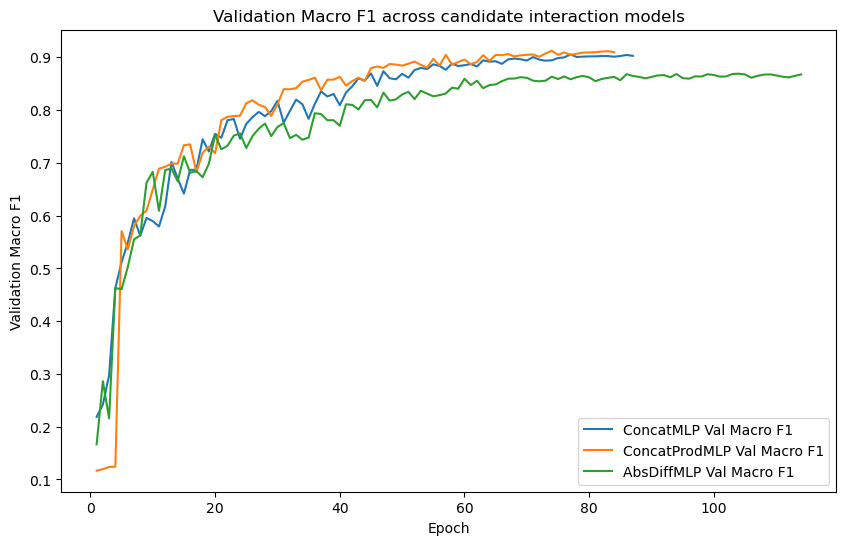

In [31]:
plt.figure(figsize=(10, 6))

for model_name, hist_df in all_histories.items():
    plt.plot(hist_df["epoch"], hist_df["val_macro_f1"], label=f"{model_name} Val Macro F1")

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation Macro F1 across candidate interaction models")
plt.legend()
plt.show()